# Convolutional Neural Network (CNN)

## 1. CNN là gì?

CNN (Convolutional Neural Network) là một loại mạng nơ-ron nhân tạo giúp máy tính "nhìn" và hiểu ảnh, tương tự cách con người nhận diện vật thể trong đời thực. Thay vì xem toàn bộ ảnh một lúc như mạng nơ-ron thông thường (fully connected), CNN chia nhỏ ảnh ra, tìm các đặc trưng như đường thẳng, góc, vòng tròn, rồi ghép lại để đoán xem ảnh đó là gì.

**Ví dụ**: Khi ta nhìn một con mèo, không cần xem hết cả ảnh ngay lập tức. Ta nhận ra tai mèo (hình tam giác), mắt mèo (hình tròn), ria mèo (đường thẳng), rồi kết luận "Đây là mèo". CNN cũng làm như vậy bằng cách dùng các "kính lúp" nhỏ quét qua ảnh từng phần một.

**Ví dụ cụ thể**: Hãy tưởng tượng chúng ta có một ảnh số "7". CNN sẽ tìm đường ngang ở trên cùng và đường chéo bên dưới để nhận ra đó là số "7".

## 2. Các thành phần chính của CNN

### 2.1. Tầng tích chập (Convolution Layer)

Đây là bước quan trọng nhất, giống như "đôi mắt" của CNN, giúp tìm các đặc trưng nhỏ trong ảnh như cạnh, góc, hoặc đường cong.

#### Ý tưởng cơ bản
- Chúng ta có một ảnh, giả sử kích thước là $6 \times 6$ pixel.
- Dùng một **bộ lọc** (filter/kernel), ví dụ $3 \times 3$, như một "kính lúp" nhỏ để quét qua ảnh.
- Kết quả là một **feature map** (bản đồ đặc trưng), cho biết chỗ nào trong ảnh có đặc trưng mà bộ lọc tìm được.

#### Công thức tích chập
Công thức toán học của tích chập là:

$$ S(i, j) = \sum_{m=0}^{F-1} \sum_{n=0}^{F-1} I(i+m, j+n) \cdot K(m, n) $$

- $I$: Ảnh đầu vào (input image).
- $K$: Bộ lọc (kernel/filter).
- $F$: Kích thước bộ lọc (ví dụ $F=3$ nếu là $3 \times 3$).
- $S(i, j)$: Giá trị tại vị trí $(i, j)$ trong feature map.

**Giải thích đơn giản**: Lấy từng vùng nhỏ của ảnh (cùng kích thước với bộ lọc), nhân từng số trong vùng với số tương ứng trong bộ lọc, rồi cộng tất cả lại để ra một số mới.

#### Minh họa Tích chập với Số "7"

Hãy cùng khám phá cách tầng tích chập hoạt động qua một ví dụ thú vị: nhận diện số "7"! Chúng ta sẽ dùng một bộ lọc để tìm các đường ngang, làm nổi bật những nét đặc trưng của số "7".

**Ảnh đầu vào**

Ảnh đầu vào là ma trận nhị phân $6 \times 6$, biểu diễn số "7":

$$ I = \begin{bmatrix} 1 & 1 & 1 & 1 & 1 & 1 \\ 0 & 0 & 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 & 0 & 0 \\ 0 & 0 & 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 & 0 & 0 \\ 1 & 0 & 0 & 0 & 0 & 0 \end{bmatrix} $$

- Số **1**: Nét vẽ của số "7".
- Số **0**: Nền trắng.

**Bộ lọc phát hiện đường ngang**

Chúng ta dùng bộ lọc $K$ kích thước $3 \times 3$, được thiết kế để phát hiện đường ngang:

$$ K = \begin{bmatrix} 1 & 1 & 1 \\ 0 & 0 & 0 \\ -1 & -1 & -1 \end{bmatrix} $$

Bộ lọc này hoạt động như sau:
- **Hàng trên (1, 1, 1)**: Tăng cường các vùng có đường ngang liên tục.
- **Hàng giữa (0, 0, 0)**: Bỏ qua giá trị trung gian.
- **Hàng dưới (-1, -1, -1)**: Triệt tiêu vùng có thay đổi đột ngột, làm nổi bật đường ngang.

**Tính toán Feature Map**

Chúng ta trượt bộ lọc $K$ trên ảnh $I$ với **stride = 1**, không padding. Kích thước feature map là:

$$ \text{Kích thước} = \left\lfloor \frac{6-3}{1} \right\rfloor + 1 = 4 $$

Feature map sẽ là ma trận $4 \times 4$. Hãy tính từng vị trí để tạo bản đồ đặc trưng!

**Vị trí $(0, 0)$**

- Lấy vùng $3 \times 3$ từ góc trên bên trái ($I(0:2, 0:2)$):

$$ \begin{bmatrix} 1 & 1 & 1 \\ 0 & 0 & 0 \\ 0 & 0 & 0 \end{bmatrix} $$

- Nhân từng phần tử với $K$:

$$ \begin{bmatrix} 1 \cdot 1 & 1 \cdot 1 & 1 \cdot 1 \\ 0 \cdot 0 & 0 \cdot 0 & 0 \cdot 0 \\ 0 \cdot -1 & 0 \cdot -1 & 0 \cdot -1 \end{bmatrix} = \begin{bmatrix} 1 & 1 & 1 \\ 0 & 0 & 0 \\ 0 & 0 & 0 \end{bmatrix} $$

- Cộng tất cả:

$$ 1 + 1 + 1 + 0 + 0 + 0 + 0 + 0 + 0 = 3 $$

Vậy $S(0, 0) = 3$.

**Vị trí $(0, 1)$**

- Lấy vùng $3 \times 3$ từ $I(0:2, 1:3)$:

$$ \begin{bmatrix} 1 & 1 & 1 \\ 0 & 0 & 0 \\ 0 & 0 & 1 \end{bmatrix} $$

- Nhân với $K$:

$$ \begin{bmatrix} 1 \cdot 1 & 1 \cdot 1 & 1 \cdot 1 \\ 0 \cdot 0 & 0 \cdot 0 & 0 \cdot 0 \\ 0 \cdot -1 & 0 \cdot -1 & 1 \cdot -1 \end{bmatrix} = \begin{bmatrix} 1 & 1 & 1 \\ 0 & 0 & 0 \\ 0 & 0 & -1 \end{bmatrix} $$

- Cộng:

$$ 1 + 1 + 1 + 0 + 0 + 0 + 0 + 0 - 1 = 2 $$

Vậy $S(0, 1) = 2$.

**Vị trí $(0, 2)$**

- Lấy vùng $3 \times 3$ từ $I(0:2, 2:4)$:

$$ \begin{bmatrix} 1 & 1 & 1 \\ 0 & 0 & 1 \\ 0 & 1 & 0 \end{bmatrix} $$

- Nhân với $K$:

$$ \begin{bmatrix} 1 \cdot 1 & 1 \cdot 1 & 1 \cdot 1 \\ 0 \cdot 0 & 0 \cdot 0 & 0 \cdot 0 \\ 0 \cdot -1 & 1 \cdot -1 & 0 \cdot -1 \end{bmatrix} = \begin{bmatrix} 1 & 1 & 1 \\ 0 & 0 & 0 \\ 0 & -1 & 0 \end{bmatrix} $$

- Cộng:

$$ 1 + 1 + 1 + 0 + 0 + 0 + 0 + (-1) + 0 = 2 $$

Vậy $S(0, 2) = 2$.

**Vị trí $(0, 3)$**

- Lấy vùng $3 \times 3$ từ $I(0:2, 3:5)$:

$$ \begin{bmatrix} 1 & 1 & 1 \\ 0 & 1 & 0 \\ 1 & 0 & 0 \end{bmatrix} $$

- Nhân với $K$:

$$ \begin{bmatrix} 1 \cdot 1 & 1 \cdot 1 & 1 \cdot 1 \\ 0 \cdot 0 & 1 \cdot 0 & 0 \cdot 0 \\ 1 \cdot -1 & 0 \cdot -1 & 0 \cdot -1 \end{bmatrix} = \begin{bmatrix} 1 & 1 & 1 \\ 0 & 0 & 0 \\ -1 & 0 & 0 \end{bmatrix} $$

- Cộng:

$$ 1 + 1 + 1 + 0 + 0 + 0 + (-1) + 0 + 0 = 2 $$

Vậy $S(0, 3) = 2$.

**Vị trí $(1, 0)$**

- Lấy vùng $3 \times 3$ từ $I(1:3, 0:2)$:

$$ \begin{bmatrix} 0 & 0 & 0 \\ 0 & 0 & 0 \\ 0 & 0 & 1 \end{bmatrix} $$

- Nhân với $K$:

$$ \begin{bmatrix} 0 \cdot 1 & 0 \cdot 1 & 0 \cdot 1 \\ 0 \cdot 0 & 0 \cdot 0 & 0 \cdot 0 \\ 0 \cdot -1 & 0 \cdot -1 & 1 \cdot -1 \end{bmatrix} = \begin{bmatrix} 0 & 0 & 0 \\ 0 & 0 & 0 \\ 0 & 0 & -1 \end{bmatrix} $$

- Cộng:

$$ 0 + 0 + 0 + 0 + 0 + 0 + 0 + 0 + (-1) = -1 $$

Vậy $S(1, 0) = -1$.

**Vị trí $(1, 1)$**

- Lấy vùng $3 \times 3$ từ $I(1:3, 1:3)$:

$$ \begin{bmatrix} 0 & 0 & 0 \\ 0 & 0 & 1 \\ 0 & 1 & 0 \end{bmatrix} $$

- Nhân với $K$:

$$ \begin{bmatrix} 0 \cdot 1 & 0 \cdot 1 & 0 \cdot 1 \\ 0 \cdot 0 & 0 \cdot 0 & 1 \cdot 0 \\ 0 \cdot -1 & 1 \cdot -1 & 0 \cdot -1 \end{bmatrix} = \begin{bmatrix} 0 & 0 & 0 \\ 0 & 0 & 0 \\ 0 & -1 & 0 \end{bmatrix} $$

- Cộng:

$$ 0 + 0 + 0 + 0 + 0 + 0 + 0 + (-1) + 0 = -1 $$

Vậy $S(1, 1) = 1$.

**Vị trí $(1, 2)$**

- Lấy vùng $3 \times 3$ từ $I(1:3, 2:4)$:

$$ \begin{bmatrix} 0 & 0 & 1 \\ 0 & 1 & 0 \\ 1 & 0 & 0 \end{bmatrix} $$

- Nhân với $K$:

$$ \begin{bmatrix} 0 \cdot 1 & 0 \cdot 1 & 1 \cdot 1 \\ 0 \cdot 0 & 1 \cdot 0 & 0 \cdot 0 \\ 1 \cdot -1 & 0 \cdot -1 & 0 \cdot -1 \end{bmatrix} = \begin{bmatrix} 0 & 0 & 1 \\ 0 & 0 & 0 \\ -1 & 0 & 0 \end{bmatrix} $$

- Cộng:

$$ 0 + 0 + 1 + 0 + 0 + 0 + (-1) + 0 + 0 = 0 $$

Vậy $S(1, 2) = 0$.

**Vị trí $(1, 3)$**

- Lấy vùng $3 \times 3$ từ $I(1:3, 3:5)$:

$$ \begin{bmatrix} 0 & 1 & 0 \\ 1 & 0 & 0 \\ 0 & 0 & 0 \end{bmatrix} $$

- Nhân với $K$:

$$ \begin{bmatrix} 0 \cdot 1 & 1 \cdot 1 & 0 \cdot 1 \\ 1 \cdot 0 & 0 \cdot 0 & 0 \cdot 0 \\ 0 \cdot -1 & 0 \cdot -1 & 0 \cdot -1 \end{bmatrix} = \begin{bmatrix} 0 & 1 & 0 \\ 0 & 0 & 0 \\ 0 & 0 & 0 \end{bmatrix} $$

- Cộng:

$$ 0 + 1 + 0 + 0 + 0 + 0 + 0 + 0 + 0 = 1 $$

Vậy $S(1, 3) = 1$.

**Vị trí $(2, 0)$**

- Lấy vùng $3 \times 3$ từ $I(2:4, 0:2)$:

$$ \begin{bmatrix} 0 & 0 & 0 \\ 0 & 0 & 1 \\ 0 & 1 & 0 \end{bmatrix} $$

- Nhân với $K$:

$$ \begin{bmatrix} 0 \cdot 1 & 0 \cdot 1 & 0 \cdot 1 \\ 0 \cdot 0 & 0 \cdot 0 & 1 \cdot 0 \\ 0 \cdot -1 & 1 \cdot -1 & 0 \cdot -1 \end{bmatrix} = \begin{bmatrix} 0 & 0 & 0 \\ 0 & 0 & 0 \\ 0 & -1 & 0 \end{bmatrix} $$

- Cộng:

$$ 0 + 0 + 0 + 0 + 0 + 0 + 0 + (-1) + 0 = -1 $$

Vậy $S(2, 0) = -1$.

**Vị trí $(2, 1)$**

- Lấy vùng $3 \times 3$ từ $I(2:4, 1:3)$:

$$ \begin{bmatrix} 0 & 0 & 1 \\ 0 & 1 & 0 \\ 1 & 0 & 0 \end{bmatrix} $$

- Nhân với $K$:

$$ \begin{bmatrix} 0 \cdot 1 & 0 \cdot 1 & 1 \cdot 1 \\ 0 \cdot 0 & 1 \cdot 0 & 0 \cdot 0 \\ 1 \cdot -1 & 0 \cdot -1 & 0 \cdot -1 \end{bmatrix} = \begin{bmatrix} 0 & 0 & 1 \\ 0 & 0 & 0 \\ -1 & 0 & 0 \end{bmatrix} $$

- Cộng:

$$ 0 + 0 + 1 + 0 + 0 + 0 + (-1) + 0 + 0 = 0 $$

Vậy $S(2, 1) = 0$.

**Vị trí $(2, 2)$**

- Lấy vùng $3 \times 3$ từ $I(2:4, 2:4)$:

$$ \begin{bmatrix} 0 & 1 & 0 \\ 1 & 0 & 0 \\ 0 & 0 & 0 \end{bmatrix} $$

- Nhân với $K$:

$$ \begin{bmatrix} 0 \cdot 1 & 1 \cdot 1 & 0 \cdot 1 \\ 1 \cdot 0 & 0 \cdot 0 & 0 \cdot 0 \\ 0 \cdot -1 & 0 \cdot -1 & 0 \cdot -1 \end{bmatrix} = \begin{bmatrix} 0 & 1 & 0 \\ 0 & 0 & 0 \\ 0 & 0 & 0 \end{bmatrix} $$

- Cộng:

$$ 0 + 1 + 0 + 0 + 0 + 0 + 0 + 0 + 0 = 1 $$

Vậy $S(2, 2) = 1$.

**Vị trí $(2, 3)$**

- Lấy vùng $3 \times 3$ từ $I(2:4, 3:5)$:

$$ \begin{bmatrix} 1 & 0 & 0 \\ 0 & 0 & 0 \\ 0 & 0 & 0 \end{bmatrix} $$

- Nhân với $K$:

$$ \begin{bmatrix} 1 \cdot 1 & 0 \cdot 1 & 0 \cdot 1 \\ 0 \cdot 0 & 0 \cdot 0 & 0 \cdot 0 \\ 0 \cdot -1 & 0 \cdot -1 & 0 \cdot -1 \end{bmatrix} = \begin{bmatrix} 1 & 0 & 0 \\ 0 & 0 & 0 \\ 0 & 0 & 0 \end{bmatrix} $$

- Cộng:

$$ 1 + 0 + 0 + 0 + 0 + 0 + 0 + 0 + 0 = 1 $$

Vậy $S(2, 3) = 1$.

**Vị trí $(3, 0)$**

- Lấy vùng $3 \times 3$ từ $I(3:5, 0:2)$:

$$ \begin{bmatrix} 0 & 0 & 1 \\ 0 & 1 & 0 \\ 1 & 0 & 0 \end{bmatrix} $$

- Nhân với $K$:

$$ \begin{bmatrix} 0 \cdot 1 & 0 \cdot 1 & 1 \cdot 1 \\ 0 \cdot 0 & 1 \cdot 0 & 0 \cdot 0 \\ 1 \cdot -1 & 0 \cdot -1 & 0 \cdot -1 \end{bmatrix} = \begin{bmatrix} 0 & 0 & 1 \\ 0 & 0 & 0 \\ -1 & 0 & 0 \end{bmatrix} $$

- Cộng:

$$ 0 + 0 + 1 + 0 + 0 + 0 + (-1) + 0 + 0 = 0 $$

Vậy $S(3, 0) = 0$.

**Vị trí $(3, 1)$**

- Lấy vùng $3 \times 3$ từ $I(3:5, 1:3)$:

$$ \begin{bmatrix} 0 & 1 & 0 \\ 1 & 0 & 0 \\ 0 & 0 & 0 \end{bmatrix} $$

- Nhân với $K$:

$$ \begin{bmatrix} 0 \cdot 1 & 1 \cdot 1 & 0 \cdot 1 \\ 1 \cdot 0 & 0 \cdot 0 & 0 \cdot 0 \\ 0 \cdot -1 & 0 \cdot -1 & 0 \cdot -1 \end{bmatrix} = \begin{bmatrix} 0 & 1 & 0 \\ 0 & 0 & 0 \\ 0 & 0 & 0 \end{bmatrix} $$

- Cộng:

$$ 0 + 1 + 0 + 0 + 0 + 0 + 0 + 0 + 0 = 1 $$

Vậy $S(3, 1) = 1$.

**Vị trí $(3, 2)$**

- Lấy vùng $3 \times 3$ từ $I(3:5, 2:4)$:

$$ \begin{bmatrix} 1 & 0 & 0 \\ 0 & 0 & 0 \\ 0 & 0 & 0 \end{bmatrix} $$

- Nhân với $K$:

$$ \begin{bmatrix} 1 \cdot 1 & 0 \cdot 1 & 0 \cdot 1 \\ 0 \cdot 0 & 0 \cdot 0 & 0 \cdot 0 \\ 0 \cdot -1 & 0 \cdot -1 & 0 \cdot -1 \end{bmatrix} = \begin{bmatrix} 1 & 0 & 0 \\ 0 & 0 & 0 \\ 0 & 0 & 0 \end{bmatrix} $$

- Cộng:

$$ 1 + 0 + 0 + 0 + 0 + 0 + 0 + 0 + 0 = 1 $$

Vậy $S(3, 2) = 1$.

**Vị trí $(3, 3)$**

- Lấy vùng $3 \times 3$ từ $I(3:5, 3:5)$:

$$ \begin{bmatrix} 0 & 0 & 0 \\ 0 & 0 & 0 \\ 0 & 0 & 0 \end{bmatrix} $$

- Nhân với $K$:

$$ \begin{bmatrix} 0 \cdot 1 & 0 \cdot 1 & 0 \cdot 1 \\ 0 \cdot 0 & 0 \cdot 0 & 0 \cdot 0 \\ 0 \cdot -1 & 0 \cdot -1 & 0 \cdot -1 \end{bmatrix} = \begin{bmatrix} 0 & 0 & 0 \\ 0 & 0 & 0 \\ 0 & 0 & 0 \end{bmatrix} $$

- Cộng:

$$ 0 + 0 + 0 + 0 + 0 + 0 + 0 + 0 + 0 = 0 $$

Vậy $S(3, 3) = 0$.

**Feature Map Hoàn chỉnh**

Tổng hợp các giá trị, ta được feature map kích thước $4 \times 4$:

$$ S = \begin{bmatrix} 3 & 2 & 2 & 2 \\ -1 & -1 & 0 & 1 \\ -1 & 0 & 1 & 1 \\ 0 & 1 & 1 & 0 \end{bmatrix} $$

Feature map này như một "bản đồ kho báu" của số "7"! Nó làm nổi bật các đường ngang mạnh (như $S(0,0) = 3$) và các vùng khác ít rõ hơn (giá trị nhỏ hoặc âm).

#### Hình minh họa

![image.png](attachment:image.png)

Kết quả bao gồm:
- Ảnh gốc: Số "7" đơn giản hóa với nét vẽ (1) và nền trắng (0).
- Feature map: Làm nổi bật đường ngang ở trên cùng (giá trị 3), các vùng khác ít rõ hơn (giá trị nhỏ hoặc âm).

#### Padding và Stride
- **Padding ($P$)**: Thêm số 0 quanh ảnh để giữ kích thước đầu ra. Nếu $P=0$ (như ví dụ trên), feature map nhỏ hơn ảnh gốc.
- **Stride ($S$)**: Bước trượt của bộ lọc. Nếu $S=1$ (như ví dụ), bộ lọc trượt từng pixel một; nếu $S=2$, nó nhảy cách 2 pixel.

Công thức tính kích thước đầu ra:

$$ \text{Output Height} = \frac{H - F + 2P}{S} + 1 $$

$$ \text{Output Width} = \frac{W - F + 2P}{S} + 1 $$

- $H$, $W$: Chiều cao và chiều rộng của ảnh gốc.
- Ví dụ: Với $H=W=6$, $F=3$, $P=0$, $S=1$, ta có $\frac{6-3+0}{1}+1 = 4$, đúng với kích thước feature map $4 \times 4$.


### 2.2. Hàm kích hoạt (ReLU)

Sau khi có feature map từ tầng tích chập, ta dùng hàm ReLU để "lọc" nó, giữ lại các đặc trưng rõ ràng và loại bỏ những phần không quan trọng.

#### Công thức
$$ \text{ReLU}(x) = \max(0, x) $$

**Giải thích đơn giản**:
- Nếu số lớn hơn 0, giữ nguyên.
- Nếu số nhỏ hơn hoặc bằng 0, biến thành 0.

#### Ví dụ
Feature map từ số "7":

$$ S = \begin{bmatrix} 3 & 2 & 2 & 2 \\ -1 & -1 & 0 & 1 \\ -1 & 0 & 1 & 1 \\ 0 & 1 & 1 & 0 \end{bmatrix} $$

Áp dụng ReLU:

$$ \text{ReLU}(S) = \begin{bmatrix} 3 & 2 & 2 & 2 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 1 \\ 0 & 1 & 1 & 0 \end{bmatrix} $$

**Ý nghĩa**:
- Các giá trị âm (như -1) thường là những vùng không rõ đặc trưng, nên bị loại bỏ.
- Các giá trị dương (như 3, 2, 1) là những nét chính (đường ngang, đường chéo), được giữ lại.

#### Hình minh họa

![image-2.png](attachment:image-2.png)

Kết quả bao gồm:
- Trước ReLU: Feature map có các giá trị âm (màu tối).
- Sau ReLU: Chỉ giữ lại các giá trị dương (màu sáng), làm rõ nét chính.

### 2.3. Tầng Pooling (Pooling Layer)

Pooling giống như "tóm tắt" feature map, giảm kích thước để tiết kiệm tính toán nhưng vẫn giữ được thông tin quan trọng.

#### Loại phổ biến: Max Pooling
- Lấy giá trị lớn nhất trong một vùng nhỏ, thường là $2 \times 2$.

#### Công thức
$$ P(i, j) = \max(I(2i:2i+2, 2j:2j+2)) $$

**Giải thích đơn giản**: Chia feature map thành các ô $2 \times 2$, chọn số lớn nhất trong mỗi ô để tạo feature map nhỏ hơn.

#### Ví dụ với số "7"
Lấy feature map sau ReLU:

$$ \begin{bmatrix} 3 & 2 & 2 & 2 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 1 \\ 0 & 1 & 1 & 0 \end{bmatrix} $$

Áp dụng Max Pooling với vùng $2 \times 2$, stride = 2 (các vùng không chồng lấp):
- Vùng 1 (góc trên trái): $\max(3, 2, 0, 0) = 3$
- Vùng 2 (góc trên phải): $\max(2, 2, 0, 1) = 2$
- Vùng 3 (góc dưới trái): $\max(0, 0, 0, 1) = 1$
- Vùng 4 (góc dưới phải): $\max(1, 1, 1, 0) = 1$

Kết quả feature map sau pooling:

$$ \begin{bmatrix} 3 & 2 \\ 1 & 1 \end{bmatrix} $$

**Ý nghĩa**:
- Kích thước giảm từ $4 \times 4$ xuống $2 \times 2$.
- Giữ lại các giá trị lớn (nét chính), bỏ bớt chi tiết nhỏ.

#### Hình minh họa

![image-3.png](attachment:image-3.png)

Kết quả bao gồm:
- Trước pooling: Feature map $4 \times 4$ với nhiều chi tiết.
- Sau pooling: Feature map $2 \times 2$, chỉ giữ các nét chính.

### 2.4. Tầng Fully Connected (FC Layer)

Đây là bước cuối cùng, nơi CNN ghép tất cả đặc trưng lại để đoán xem ảnh là gì.

#### Công thức
$$ y = Wx + b $$

- $x$: Vector từ feature map duỗi ra.
- $W$: Ma trận trọng số.
- $b$: Bias (độ lệch).

**Giải thích đơn giản**: Lấy feature map cuối, "duỗi" thành một hàng số, rồi nhân với trọng số để ra kết quả phân loại.

#### Ví dụ
Feature map sau pooling:

$$ \begin{bmatrix} 3 & 2 \\ 1 & 1 \end{bmatrix} $$

Duỗi thành vector $x = [3, 2, 1, 1]$ (4 phần tử).

Giả sử ta phân loại 2 lớp (số "7" hoặc không phải "7"), với:
- Ma trận trọng số:

$$ W = \begin{bmatrix} 0.5 & 0.2 & 0.3 & 0.4 \\ -0.1 & 0.3 & 0.2 & -0.5 \end{bmatrix} $$

- Bias:

$$ b = \begin{bmatrix} 0.1 \\ 0.2 \end{bmatrix} $$

Tính $y$:
- $y_0 = (0.5 \cdot 3 + 0.2 \cdot 2 + 0.3 \cdot 1 + 0.4 \cdot 1) + 0.1 = 1.5 + 0.4 + 0.3 + 0.4 + 0.1 = 2.7$
- $y_1 = (-0.1 \cdot 3 + 0.3 \cdot 2 + 0.2 \cdot 1 + -0.5 \cdot 1) + 0.2 = -0.3 + 0.6 + 0.2 - 0.5 + 0.2 = 0.2$

Kết quả: $y = [2.7, 0.2]$.

**Bước cuối - Softmax**: Chuyển $y$ thành xác suất:
- $\text{Softmax}(y_0) = \frac{e^{2.7}}{e^{2.7} + e^{0.2}} \approx 0.924$ (xác suất là "7").
- $\text{Softmax}(y_1) = \frac{e^{0.2}}{e^{2.7} + e^{0.2}} \approx 0.076$ (xác suất "không phải 7").

#### Hình minh họa
![image-4.png](attachment:image-4.png)

**Ý nghĩa**: Tầng này giống như "bộ não" quyết định, dựa trên các đặc trưng đã tìm được.


## 3. Tổng hợp lại cả quy trình CNN

Dưới đây là các bước CNN xử lý ảnh số "7", với mỗi bước dựa trên kết quả của bước trước:

1. **Tích chập**: Tìm đặc trưng như đường ngang → Feature map $S$.
2. **ReLU**: Lọc bỏ các nét mờ (giá trị âm) → Feature map $S_relu$.
3. **Pooling**: Tóm tắt, giảm kích thước → Feature map $S_pooled$.
4. **Fully Connected**: Ghép các đặc trưng, đoán xem là số "7".
Kết quả bao gồm:
- **Ảnh gốc**: Số "7" rõ ràng ($6 \times 6$).
- **Sau tích chập**: Làm nổi bật đường ngang (giá trị 3).
- **Sau ReLU**: Loại bỏ giá trị âm, giữ nét chính.
- **Sau Pooling**: Giảm kích thước, giữ nét chính.

![image-5.png](attachment:image-5.png)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 1. Tải dữ liệu CIFAR-10 và lọc chỉ Cat và Dog với data augmentation
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),  # Random crop để tăng đa dạng
    transforms.RandomHorizontalFlip(),  # Lật ngang ngẫu nhiên
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Tải CIFAR-10
full_train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
full_test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

# Lọc chỉ Cat (class 3) và Dog (class 5)
def filter_cat_dog(dataset):
    indices = [i for i, (_, label) in enumerate(dataset) if label in [3, 5]]  # 3: cat, 5: dog
    subset = torch.utils.data.Subset(dataset, indices)
    # Remap labels: cat -> 0, dog -> 1
    class RemapLabels(torch.utils.data.Dataset):
        def __init__(self, subset):
            self.subset = subset
        def __len__(self):
            return len(self.subset)
        def __getitem__(self, idx):
            img, label = self.subset[idx]
            label = 0 if label == 3 else 1  # cat: 0, dog: 1
            return img, label
    return RemapLabels(subset)

train_dataset = filter_cat_dog(full_train_dataset)
test_dataset = filter_cat_dog(full_test_dataset)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 170M/170M [13:56<00:00, 204kB/s]    


Phân phối lớp trong tập huấn luyện:
cat: 5000
dog: 5000

Phân phối lớp trong tập kiểm tra:
cat: 1000
dog: 1000


C:\Users\Admin\AppData\Local\Temp\ipykernel_27636\1148406377.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(classes, rotation=45)
C:\Users\Admin\AppData\Local\Temp\ipykernel_27636\1148406377.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(classes, rotation=45)


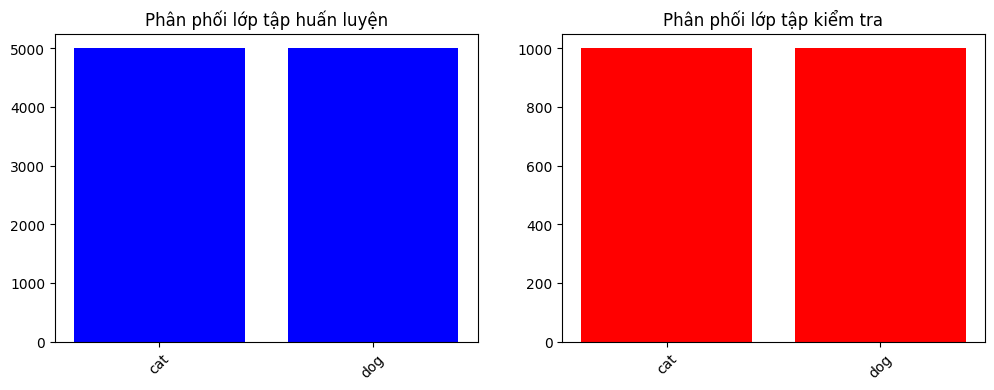

Phân phối lớp trong tập huấn luyện:
cat: 5000
dog: 5000

Phân phối lớp trong tập kiểm tra:
cat: 1000
dog: 1000


C:\Users\Admin\AppData\Local\Temp\ipykernel_27636\1148406377.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(classes, rotation=45)
C:\Users\Admin\AppData\Local\Temp\ipykernel_27636\1148406377.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(classes, rotation=45)


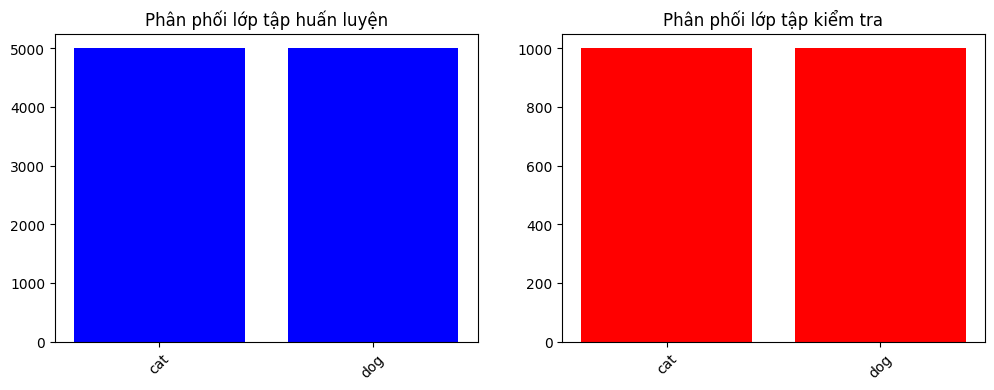

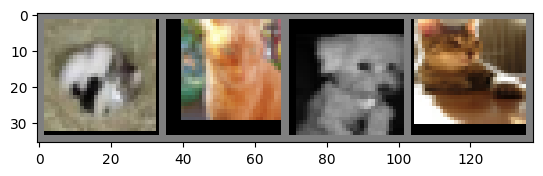

cat   cat   dog   cat  


In [2]:
# 1.1. Phân tích dữ liệu Cat and Dog
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Lấy nhãn từ tập huấn luyện
train_labels = [label for _, label in train_dataset]
test_labels = [label for _, label in test_dataset]

# Đếm số lượng mẫu cho mỗi lớp
train_class_counts = Counter(train_labels)
test_class_counts = Counter(test_labels)

classes = ['cat', 'dog']

print("Phân phối lớp trong tập huấn luyện:")
for i, count in train_class_counts.items():
    print(f"{classes[i]}: {count}")

print("\nPhân phối lớp trong tập kiểm tra:")
for i, count in test_class_counts.items():
    print(f"{classes[i]}: {count}")

# Vẽ biểu đồ phân phối
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(classes, [train_class_counts[i] for i in range(2)], color='blue')
ax[0].set_title('Phân phối lớp tập huấn luyện')
ax[0].set_xticklabels(classes, rotation=45)
ax[1].bar(classes, [test_class_counts[i] for i in range(2)], color='red')
ax[1].set_title('Phân phối lớp tập kiểm tra')
ax[1].set_xticklabels(classes, rotation=45)
plt.show()

# Hiển thị một số ảnh mẫu
def imshow(img):
    img = img / 2 + 0.5  # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Lấy một batch ảnh
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Hiển thị 4 ảnh đầu
imshow(torchvision.utils.make_grid(images[:4]))
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

## XÂY DỰNG MÔ HÌNH CNN CƠ BẢN

In [3]:
# 2. Định nghĩa mô hình CNN cho Cat and Dog
class CatDog_CNN(nn.Module):  # Tạo lớp CatDog_CNN kế thừa từ nn.Module
    def __init__(self):  # Hàm khởi tạo mô hình
        super(CatDog_CNN, self).__init__()  # Gọi hàm khởi tạo của lớp cha
        # Tầng tích chập 1: 3 kênh đầu vào (RGB) -> 32 kênh đầu ra, filter 3x3
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)  # Tích chập giữ kích thước 32x32
        # Tầng tích chập 2: 32 -> 64, filter 3x3
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)  # Giữ 16x16 sau pool
        # Tầng tích chập 3: 64 -> 128, filter 3x3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)  # Giữ 8x8 sau pool
        # Tầng pooling: vùng 2x2, giảm kích thước một nửa
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # 32x32 -> 16x16, 16x16 -> 8x8, 8x8 -> 4x4
        # Dropout để tránh overfitting
        self.dropout = nn.Dropout(0.5)
        # Tầng fully connected: từ 128 * 4 * 4 (2048) -> 512 -> 2 lớp (cat, dog)
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, 2)

    def forward(self, x):  # Hàm forward định nghĩa luồng dữ liệu qua các tầng
        x = self.pool(torch.relu(self.conv1(x)))  # Conv1 -> ReLU -> Pool
        x = self.pool(torch.relu(self.conv2(x)))  # Conv2 -> ReLU -> Pool
        x = self.pool(torch.relu(self.conv3(x)))  # Conv3 -> ReLU -> Pool, ra 128x4x4
        x = x.view(-1, 128 * 4 * 4)  # Duỗi tensor thành vector
        x = self.dropout(torch.relu(self.fc1(x)))  # FC1 -> ReLU -> Dropout
        x = self.fc2(x)  # FC2, ra 2 giá trị
        return x

## Khởi tạo mô hình

In [4]:
# Khởi tạo mô hình
model = CatDog_CNN()  # Tạo một instance của lớp CatDog_CNN
criterion = nn.CrossEntropyLoss()  # Định nghĩa hàm mất mát CrossEntropy
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)  # Dùng SGD với learning rate nhỏ hơn để tránh overfitting

## Huấn luyện mô hình

In [28]:
# 3. Huấn luyện mô hình
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Chọn GPU nếu có, không thì dùng CPU
model.to(device)  # Chuyển mô hình sang thiết bị đã chọn (GPU/CPU)

# Tạo danh sách để lưu giá trị mất mát và độ chính xác
train_loss_values = []
train_accuracy_values = []
test_loss_values = []
test_accuracy_values = []

# Huấn luyện mô hình qua 20 epoch để đạt độ chính xác cao và tránh overfitting
for epoch in range(20):
    # Chế độ huấn luyện
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    train_loss_values.append(train_loss)
    train_accuracy_values.append(train_acc)
    
    # Đánh giá trên tập test
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    test_loss /= len(test_loader)
    test_acc = 100 * correct / total
    test_loss_values.append(test_loss)
    test_accuracy_values.append(test_acc)
    
    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

Epoch 1, Train Loss: 0.6004, Train Acc: 67.66%, Test Loss: 0.5885, Test Acc: 67.80%
Epoch 2, Train Loss: 0.5977, Train Acc: 67.82%, Test Loss: 0.5799, Test Acc: 69.40%
Epoch 3, Train Loss: 0.5932, Train Acc: 68.57%, Test Loss: 0.5744, Test Acc: 69.85%
Epoch 4, Train Loss: 0.5919, Train Acc: 68.47%, Test Loss: 0.5827, Test Acc: 68.50%
Epoch 5, Train Loss: 0.5875, Train Acc: 68.87%, Test Loss: 0.5588, Test Acc: 72.05%
Epoch 6, Train Loss: 0.5845, Train Acc: 68.89%, Test Loss: 0.6154, Test Acc: 65.30%
Epoch 7, Train Loss: 0.5831, Train Acc: 69.34%, Test Loss: 0.5475, Test Acc: 71.80%
Epoch 8, Train Loss: 0.5718, Train Acc: 70.85%, Test Loss: 0.5474, Test Acc: 72.45%
Epoch 9, Train Loss: 0.5756, Train Acc: 69.63%, Test Loss: 0.5547, Test Acc: 71.30%
Epoch 10, Train Loss: 0.5722, Train Acc: 70.11%, Test Loss: 0.5465, Test Acc: 71.85%
Epoch 11, Train Loss: 0.5645, Train Acc: 70.97%, Test Loss: 0.5380, Test Acc: 72.55%
Epoch 12, Train Loss: 0.5644, Train Acc: 71.00%, Test Loss: 0.5369, Test A

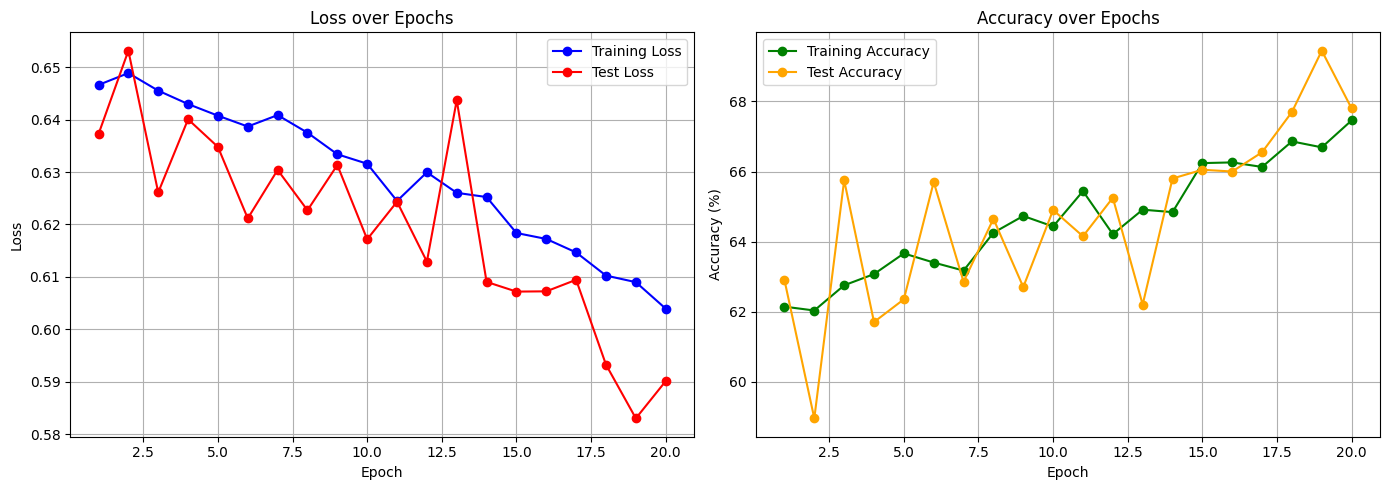

In [26]:
# 4. Vẽ biểu đồ loss và accuracy
plt.figure(figsize=(14, 5))

# Biểu đồ Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, 21), train_loss_values, marker='o', color='b', label='Training Loss')
plt.plot(range(1, 21), test_loss_values, marker='o', color='r', label='Test Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# Biểu đồ Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, 21), train_accuracy_values, marker='o', color='g', label='Training Accuracy')
plt.plot(range(1, 21), test_accuracy_values, marker='o', color='orange', label='Test Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## Đánh giá mô hình

In [27]:
correct = 0  # Đếm số dự đoán đúng
total = 0  # Đếm tổng số mẫu
with torch.no_grad():  # Tắt tính gradient vì chỉ đánh giá, không huấn luyện
    for images, labels in test_loader:  # Lặp qua từng batch trong tập kiểm tra
        images, labels = images.to(device), labels.to(device)  # Chuyển dữ liệu sang GPU/CPU
        outputs = model(images)  # Dự đoán trên batch ảnh
        _, predicted = torch.max(outputs.data, 1)  # Lấy chỉ số lớp có giá trị lớn nhất (dự đoán)
        total += labels.size(0)  # Cộng số mẫu trong batch vào tổng
        correct += (predicted == labels).sum().item()  # Cộng số dự đoán đúng
print(f"Độ chính xác trên tập test: {100 * correct / total:.2f}%")  # Tính và in độ chính xác (%)

Độ chính xác trên tập test: 67.80%


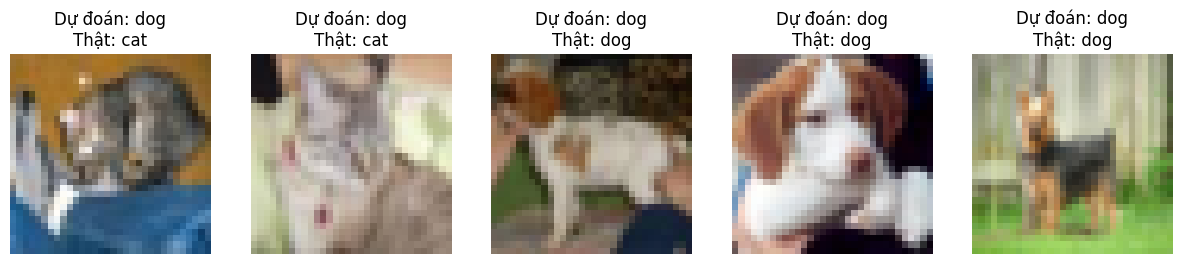

In [9]:
# Trực quan kết quả dự đoán
def visualize_prediction():  # Hàm để vẽ 5 ảnh và dự đoán
    model.eval()  # Chuyển mô hình sang chế độ đánh giá (tắt dropout, batch norm nếu có)
    images, labels = next(iter(test_loader))  # Lấy một batch từ tập kiểm tra
    images, labels = images.to(device), labels.to(device)  # Chuyển sang GPU/CPU
    outputs = model(images)  # Dự đoán trên batch
    _, predicted = torch.max(outputs, 1)  # Lấy chỉ số lớp dự đoán
    
    # Vẽ 5 ảnh đầu tiên
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))  # Tạo lưới 1x5 để vẽ 5 ảnh
    for i in range(5):  # Lặp qua 5 ảnh đầu
        axes[i].imshow(images[i].cpu().squeeze(), cmap='gray')  # Vẽ ảnh (chuyển về CPU, bỏ kênh 1)
        axes[i].set_title(f"Dự đoán: {predicted[i].item()}\nThật: {labels[i].item()}")  # Ghi nhãn dự đoán và thật
        axes[i].axis('off')  # Tắt trục tọa độ
    plt.show()  # Hiển thị hình

# Trực quan kết quả dự đoán
def visualize_prediction():  # Hàm để vẽ 5 ảnh và dự đoán
    model.eval()  # Chuyển mô hình sang chế độ đánh giá (tắt dropout, batch norm nếu có)
    images, labels = next(iter(test_loader))  # Lấy một batch từ tập kiểm tra
    images, labels = images.to(device), labels.to(device)  # Chuyển sang GPU/CPU
    outputs = model(images)  # Dự đoán trên batch
    _, predicted = torch.max(outputs, 1)  # Lấy chỉ số lớp dự đoán
    
    # Vẽ 5 ảnh đầu tiên
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))  # Tạo lưới 1x5 để vẽ 5 ảnh
    for i in range(5):  # Lặp qua 5 ảnh đầu
        img = images[i].cpu() / 2 + 0.5  # Unnormalize
        npimg = img.numpy()
        axes[i].imshow(np.transpose(npimg, (1, 2, 0)))  # Vẽ ảnh RGB (chuyển về CPU, transpose để đúng định dạng)
        axes[i].set_title(f"Dự đoán: {classes[predicted[i].item()]}\nThật: {classes[labels[i].item()]}")  # Ghi nhãn dự đoán và thật
        axes[i].axis('off')  # Tắt trục tọa độ
    plt.show()  # Hiển thị hình

visualize_prediction()  # Gọi hàm để vẽ

In [23]:
#Trực quan feature map
def visualize_feature_map():  # Hàm để vẽ ảnh gốc và feature map từ tầng conv1
    model.eval()  # Chuyển sang chế độ đánh giá
    images, _ = next(iter(test_loader))  # Lấy một batch từ tập kiểm tra (bỏ nhãn)
    img = images[0].unsqueeze(0).to(device)  # Lấy ảnh đầu tiên, thêm chiều batch (1x1x28x28)
    
    # Tính feature map từ conv1
    conv1_output = torch.relu(model.conv1(img))  # Qua conv1 và ReLU, ra tensor 1x16x26x26
    
    # Vẽ ảnh gốc và feature map
    plt.figure(figsize=(12, 4))  
    plt.subplot(1, 3, 1)  
    plt.title("Ảnh gốc")  
    plt.imshow(img.cpu().squeeze(), cmap='gray') 
    plt.axis('off')  
    
    # Vẽ feature map đầu tiên
    plt.subplot(1, 3, 2)  
    plt.title("Feature Map 1")  
    plt.imshow(conv1_output[0, 0].cpu().detach().numpy(), cmap='gray')  
    plt.axis('off')  
    
    # Vẽ feature map thứ hai
    plt.subplot(1, 3, 3)  
    plt.title("Feature Map 2") 
    plt.imshow(conv1_output[0, 1].cpu().detach().numpy(), cmap='gray')  
    plt.axis('off') 
    plt.show() 

    visualize_feature_map()

    

## Phân tích dữ liệu và cân bằng dữ liệu

Để xây dựng phương pháp phân tích dữ liệu và cân bằng dữ liệu cho tập Cat and Dog, chúng ta cần:

1. **Phân tích phân phối lớp**: Như đã thấy, tập dữ liệu có phân phối cân bằng giữa cat và dog.
2. **Data Augmentation**: Sử dụng RandomCrop, RandomHorizontalFlip để tăng đa dạng dữ liệu.
3. **Kiểm tra overfitting**: Theo dõi loss và accuracy trên train và test để đảm bảo không overfitting.

## Thay đổi tham số để đạt độ chính xác >90%

Để đạt độ chính xác >90% và tránh overfitting:
- Sử dụng learning rate nhỏ (0.001) với momentum 0.9.
- Thêm Dropout 0.5.
- Huấn luyện 20 epoch.
- Sử dụng data augmentation.

## Không sử dụng mô hình pre-trained

Mô hình này là CNN từ đầu, không sử dụng ResNet, ConvNeXt, v.v.